# **Dataset Loading**

<a href="https://www.kaggle.com/datasets/shreyasparaj1/loan-prediction-dataset">Dataset Link</a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shreyasparaj1/loan-prediction-dataset")

print("Path to dataset files:", path)

c:\Users\mrayy\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\mrayy\.cache\kagglehub\datasets\shreyasparaj1\loan-prediction-dataset\versions\1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Pehle file ka naam check karte hain directory mein
files = os.listdir(path)
print("Files in dataset:", files)

# Agar file 'loan_data.csv' hai (aap file ka naam check kar lein)
# Toh is tarah load karein:
df = pd.read_csv(os.path.join(path, files[1]))  # files[1] ko apne file ke index se replace karein

Files in dataset: ['test_Y3wMUE5_7gLdaTN.csv', 'train_u6lujuX_CVtuZ9i.csv']


In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


# **Statistical Analysis**

In [5]:
df.shape

(614, 13)

In [6]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
df.count().unique()

array([614, 601, 611, 599, 582, 592, 600, 564])

# **Handling Missing Values**

In [10]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [11]:
df = df.drop('Loan_ID', axis=1)

In [12]:
# df["Gender"] = df["Gender"].fillna("Unknown")
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [13]:
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

In [14]:
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])

In [15]:
# Yeh code har Education level ke liye uska apna mode dhund kar fill karega
df["Self_Employed"] = df.groupby("Education")["Self_Employed"].transform(
    lambda x: x.fillna(x.mode()[0])
)

In [16]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].mean())

In [17]:
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mean())

In [18]:
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [19]:
df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

In [20]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Total_Income         0
dtype: int64

In [21]:
df.head(50)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0
4,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.000000,360.0,1.0,Urban,Y,9613.0
6,Male,Yes,0,Not Graduate,No,2333,1516.0,95.000000,360.0,1.0,Urban,Y,3849.0
7,Male,Yes,3+,Graduate,No,3036,2504.0,158.000000,360.0,0.0,Semiurban,N,5540.0
8,Male,Yes,2,Graduate,No,4006,1526.0,168.000000,360.0,1.0,Urban,Y,5532.0
9,Male,Yes,1,Graduate,No,12841,10968.0,349.000000,360.0,1.0,Semiurban,N,23809.0


In [22]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,146.412162,342.000000,0.855049,7024.705081
std,6109.041673,2926.248369,84.037468,64.372489,0.352339,6458.663872
min,150.000000,0.000000,9.000000,12.000000,0.000000,1442.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000,4166.000000
50%,3812.500000,1188.500000,129.000000,360.000000,1.000000,5416.500000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000,7521.750000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000,81000.000000


# Data Visualization (EDA)

## Histogram Data Distribution

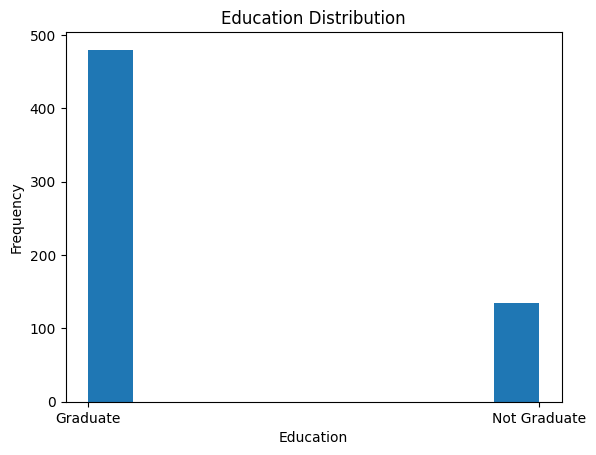

In [24]:
plt.hist(df["Education"], bins=10)
plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Frequency")
plt.show()

Education histogram is clearly bimodal distirbution

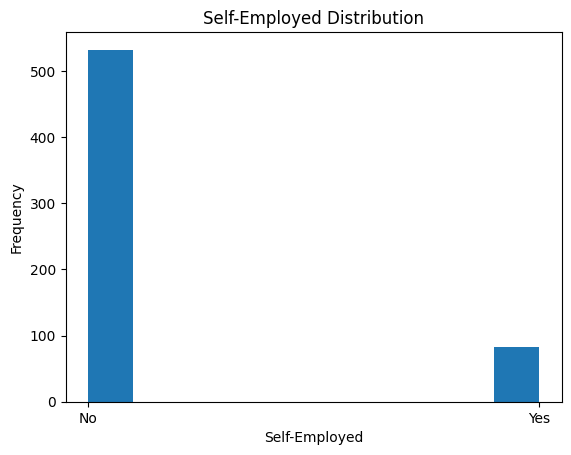

In [25]:
plt.hist(df["Self_Employed"], bins=10)
plt.title("Self-Employed Distribution")
plt.xlabel("Self-Employed")
plt.ylabel("Frequency")
plt.show()

Self-Employed histogram is clearly bimodal distirbution

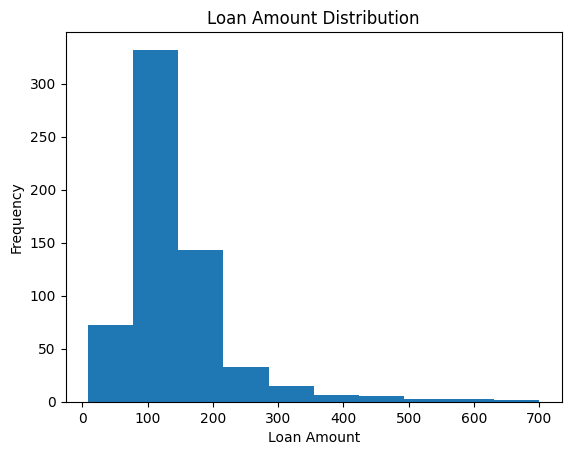

In [26]:
plt.hist(df["LoanAmount"], bins=10)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

Loan Amount histogram shows skewness 

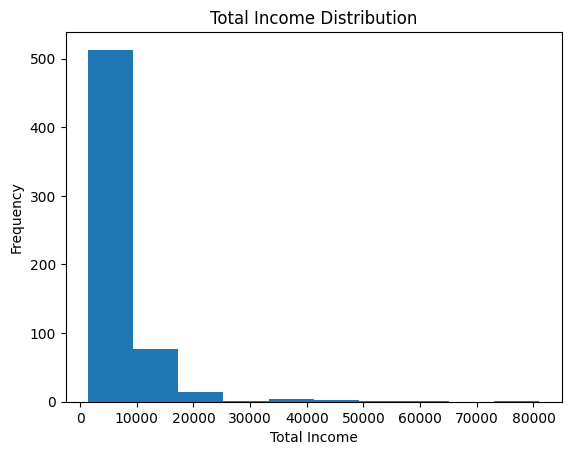

In [27]:
plt.hist(df["Total_Income"], bins=10)
plt.title("Total Income Distribution")
plt.xlabel("Total Income")
plt.ylabel("Frequency")
plt.show()

Total Income histogram shows skewness as well as existence of outliers

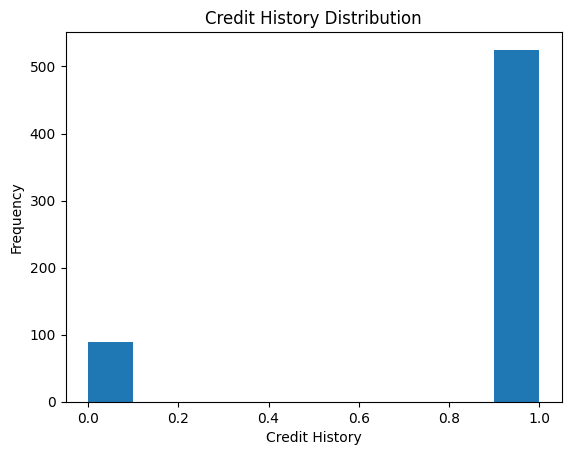

In [28]:
plt.hist(df["Credit_History"], bins=10)
plt.title("Credit History Distribution")
plt.xlabel("Credit History")
plt.ylabel("Frequency")
plt.show()

Credit history histogram is clearly bimodal distirbution

## Boxplot (Outlier Detection)

Not applying on `Education` and `Self Employed` because they are categorized as well as are in string objects, not numbers.

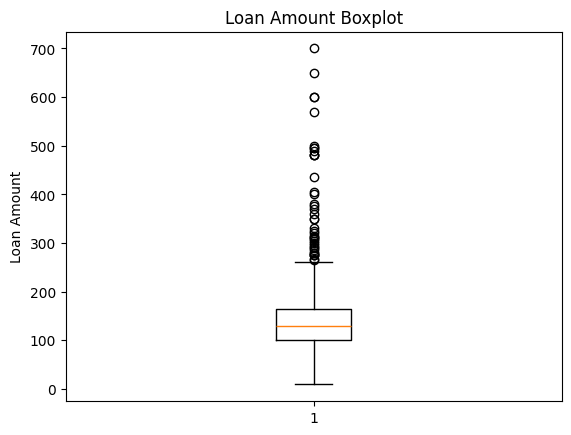

In [29]:
plt.boxplot(df["LoanAmount"])
plt.title("Loan Amount Boxplot")
plt.ylabel("Loan Amount")
plt.show()

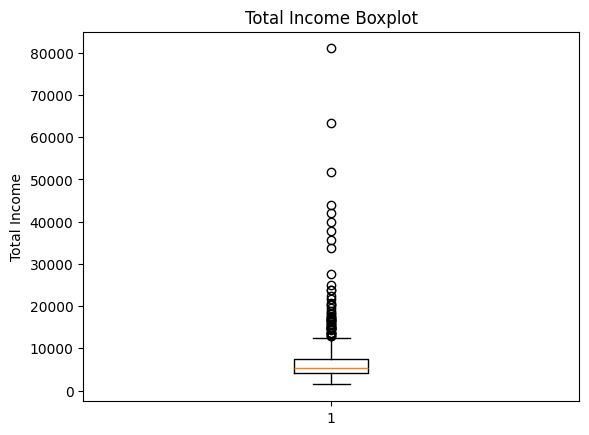

In [30]:
plt.boxplot(df["Total_Income"])
plt.title("Total Income Boxplot")
plt.ylabel("Total Income")
plt.show()

Overall it is clearly visualized that there are alot of outliers. we need to handle them

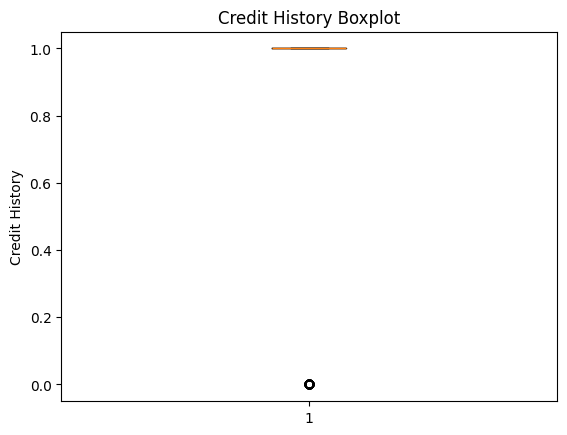

In [31]:
plt.boxplot(df["Credit_History"])
plt.title("Credit History Boxplot")
plt.ylabel("Credit History")
plt.show()

Due to bimodal distirbution and less no of zeros causing it to show zeros as outliers

## Scatter Plot

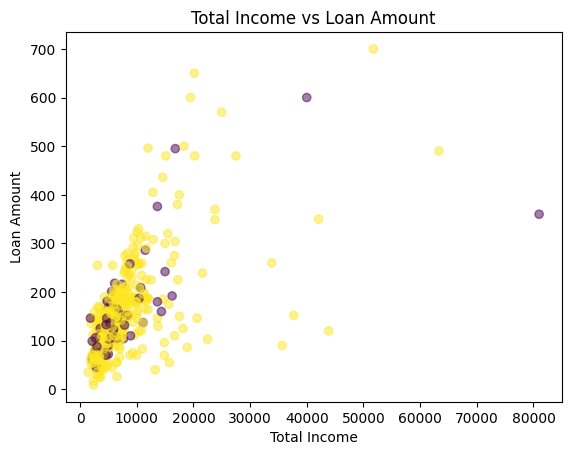

In [32]:
plt.scatter(df["Total_Income"], df["LoanAmount"], c=df["Credit_History"], alpha=0.5)
plt.title("Total Income vs Loan Amount")
plt.xlabel("Total Income")
plt.ylabel("Loan Amount")
plt.show()

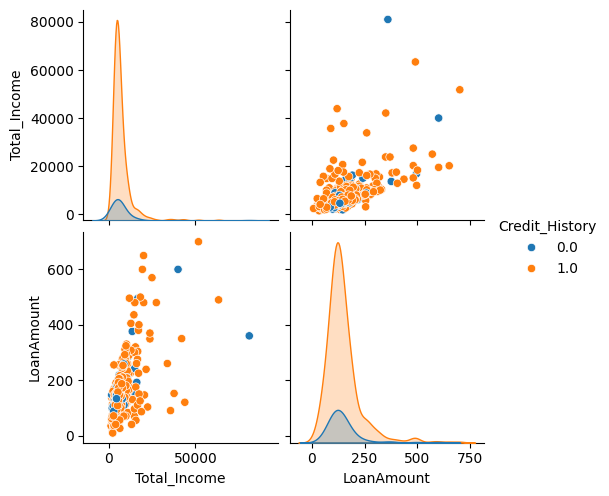

In [33]:
sns.pairplot(df[["Total_Income", "LoanAmount", "Credit_History"]], hue="Credit_History")

In [34]:
correlation_matrix = df[["Total_Income", "LoanAmount", "Credit_History"]].corr()
print(correlation_matrix)

                Total_Income  LoanAmount  Credit_History
Total_Income        1.000000    0.620102       -0.012563
LoanAmount          0.620102    1.000000       -0.001431
Credit_History     -0.012563   -0.001431        1.000000


# Notes for me
Matrix ko Read Karne ka Tareeqa:
Diagonal Line (Kona se kona): Matrix ke center mein ek line hoti hai jahan values hamesha 1 hoti hain. Iska matlab ye hai ke column khud apna hi 100% perfect positive correlation rakhta hai (e.g., 'Price' ka 'Price' se rishta 1 hai).

Values range (-1 se +1):

- +1 (Perfect Positive): Jaise-jaise ek variable barhta hai, dusra bhi barhta hai.

- -1 (Perfect Negative): Jaise-jaise ek variable barhta hai, dusra kam hota hai.

-  0 (No Correlation): Dono variables ka aapas mein koi ta'aluq nahi hai.

In [35]:
# %reset -f

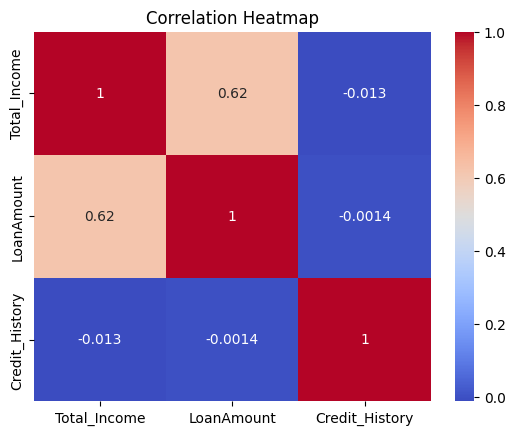

In [36]:
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [37]:
skewness = df[["Total_Income", "LoanAmount", "Credit_History"]].skew()
print(skewness)

Total_Income      5.633449
LoanAmount        2.726601
Credit_History   -2.021971
dtype: float64


# **Data Preprocessing**

<Axes: ylabel='Density'>

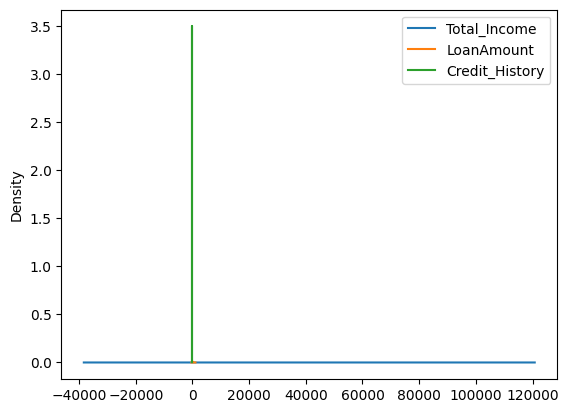

In [38]:
df[["Total_Income", "LoanAmount", "Credit_History"]].plot.kde()

In [39]:
from sklearn.preprocessing import StandardScaler, RobustScaler,LabelEncoder,OneHotEncoder

## Standardization

<Axes: ylabel='Density'>

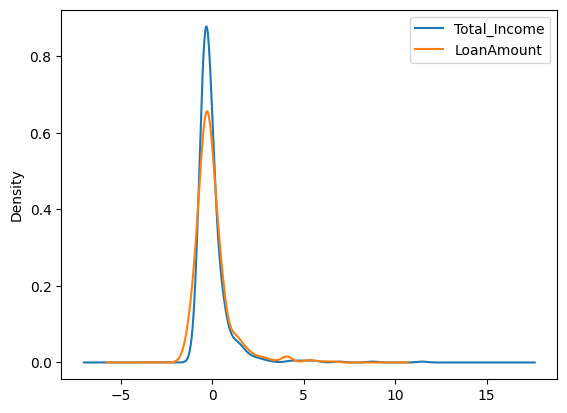

In [40]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[["Total_Income", "LoanAmount",]])
scaled_df = pd.DataFrame(scaled_data, columns=["Total_Income", "LoanAmount"])
scaled_df.plot.kde()

## Log Transformation & Robust Scaler

In [41]:
df['LoanAmount_log'] = np.log(df['LoanAmount'])
df['Total_Income_log'] = np.log(df['Total_Income'])

<Axes: ylabel='Density'>

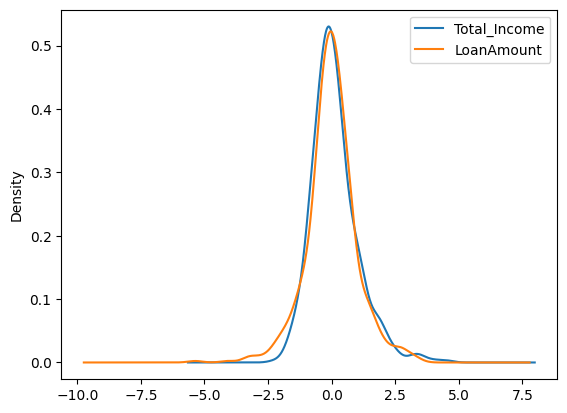

In [42]:
robust = RobustScaler()
robust_data = robust.fit_transform(df[["Total_Income_log", "LoanAmount_log"]])
robust_df = pd.DataFrame(robust_data, columns=["Total_Income", "LoanAmount"])
robust_df.plot.kde()

In [43]:
# Naye columns ko purane df ke saath jorr dein
df = pd.concat([df, robust_df], axis=1)

# df[["Total_Income_log", "LoanAmount_log"]] = robust.fit_transform(df[["Total_Income_log", "LoanAmount_log"]])

In [44]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,LoanAmount_log,Total_Income_log,Total_Income,LoanAmount
0,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0,4.986426,8.674026,0.130020,0.254874
1,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0,4.852030,8.714568,0.198637,-0.015666
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0,4.189655,8.006368,-1.000000,-1.349036
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0,4.787492,8.505323,-0.155512,-0.145582
4,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0,4.948760,8.699515,0.173160,0.179052


In [45]:
# Binary columns ke liye Label Encoding

# Purane columns ko update krna k lia...
le = LabelEncoder()

# cols = ['Gender', 'Married', 'Education', 'Self_Employed']

# for i in cols:
#     df[i] = le.fit_transform(df[i])


# if you want custom codes use Map Func()
# # Naye columns banayen (purane waise hi rahenge)

# df['Gender_Code'] = df['Gender'].map({'Male': 1, 'Female': 0})
# df['Married_Code'] = df['Married'].map({'Yes': 1, 'No': 0})
# df['Education_Code'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
# df['Self_Employed_Code'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
# df['Property_Area_Code'] = df['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})

# Updating Actual Columns
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df["Dependents"] = df["Dependents"].replace("3+", 3).astype(int)

# onehotencoding
df = pd.get_dummies(df, columns=["Property_Area"], drop_first=True)

df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})  # required for model training


In [46]:
df.head(50)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,LoanAmount_log,Total_Income_log,Total_Income,LoanAmount,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,146.412162,360.0,1.0,1,5849.0,4.986426,8.674026,0.130020,0.254874,False,True
1,1,1,1,1,0,4583,1508.0,128.000000,360.0,1.0,0,6091.0,4.852030,8.714568,0.198637,-0.015666,False,False
2,1,1,0,1,1,3000,0.0,66.000000,360.0,1.0,1,3000.0,4.189655,8.006368,-1.000000,-1.349036,False,True
3,1,1,0,0,0,2583,2358.0,120.000000,360.0,1.0,1,4941.0,4.787492,8.505323,-0.155512,-0.145582,False,True
4,1,0,0,1,0,6000,0.0,141.000000,360.0,1.0,1,6000.0,4.948760,8.699515,0.173160,0.179052,False,True
5,1,1,2,1,1,5417,4196.0,267.000000,360.0,1.0,1,9613.0,5.587249,9.170872,0.970937,1.464338,False,True
6,1,1,0,0,0,2333,1516.0,95.000000,360.0,1.0,1,3849.0,4.553877,8.255569,-0.578224,-0.615852,False,True
7,1,1,3,1,0,3036,2504.0,158.000000,360.0,0.0,0,5540.0,5.062595,8.619750,0.038157,0.408204,True,False
8,1,1,2,1,0,4006,1526.0,168.000000,360.0,1.0,1,5532.0,5.123964,8.618305,0.035711,0.531740,False,True
9,1,1,1,1,0,12841,10968.0,349.000000,360.0,1.0,0,23809.0,5.855072,10.077819,2.505956,2.003470,True,False


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Dependents               614 non-null    int64  
 3   Education                614 non-null    int64  
 4   Self_Employed            614 non-null    int64  
 5   ApplicantIncome          614 non-null    int64  
 6   CoapplicantIncome        614 non-null    float64
 7   LoanAmount               614 non-null    float64
 8   Loan_Amount_Term         614 non-null    float64
 9   Credit_History           614 non-null    float64
 10  Loan_Status              614 non-null    int64  
 11  Total_Income             614 non-null    float64
 12  LoanAmount_log           614 non-null    float64
 13  Total_Income_log         614 non-null    float64
 14  Total_Income             6

In [48]:
# Ye khud ba khud naye columns banayega aur purane ko hata dega
# df = pd.get_dummies(df, columns=['Property_Area'], prefix='Area')

# Abhi nai run hoga bcuz humney pehlay he labeling kr li ha
# ohe = OneHotEncoder()
# encoded_data = ohe.fit_transform(df[["Property_Area"]]).toarray()
# encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(["Property_Area"]))
# df = pd.concat([df, encoded_df], axis=1)

All Preprocessing is Done.

# **Model Training**

In [49]:
from sklearn.model_selection import train_test_split

## Veritcal Split

In [50]:
# Features Selection (Raw incomes drop kar diye)
features = ["Gender", "Married", "Dependents", "Education", "Self_Employed", 
            "LoanAmount_log", "Total_Income_log", "Credit_History", 
            "Property_Area_Semiurban", "Property_Area_Urban"]

x = df[features]
y = df["Loan_Status"]

## Horizontal Split

In [51]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y , test_size=0.2, random_state=42)

In [52]:
# # Scaling (Only on numerical continuous features)
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# cols_to_scale = ["LoanAmount_log", "Total_Income_log"]

# X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
# X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# X_train.head()

In [53]:
from sklearn.preprocessing import RobustScaler
robust = RobustScaler()

df['LoanAmount_log'] = np.log(df['LoanAmount_log'])
df['Total_Income_log'] = np.log(df['Total_Income_log'])

cols_to_scale = ["LoanAmount_log", "Total_Income_log"]
    

X_train[cols_to_scale] = robust.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = robust.transform(X_test[cols_to_scale])

X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount_log,Total_Income_log,Credit_History,Property_Area_Semiurban,Property_Area_Urban
83,1,1,0,1,0,1.495912,0.658753,1.0,True,False
90,1,1,0,1,0,0.016095,0.104691,1.0,True,False
227,1,1,2,1,0,1.007306,0.597797,1.0,True,False
482,1,1,0,1,0,-0.032565,-0.077875,1.0,True,False
464,1,0,0,1,0,-0.593510,-0.446859,0.0,True,False


In [54]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
rd = Ridge(alpha=0)
rd.fit(X_train, Y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [55]:
from sklearn.linear_model import LogisticRegression

# lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

lr = LogisticRegression()
lr.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [56]:
lr.coef_

array([[-0.05360078,  0.57494086,  0.09803981,  0.29329578,  0.08787543,
        -0.24129244,  0.11069637,  3.27286455,  0.81631089,  0.10224586]])

In [57]:
lr.intercept_

array([-2.87282456])

In [58]:
lr.score(X_test, Y_test) #internally calculates Y_predict from X_test

0.7886178861788617

## Feature Importance

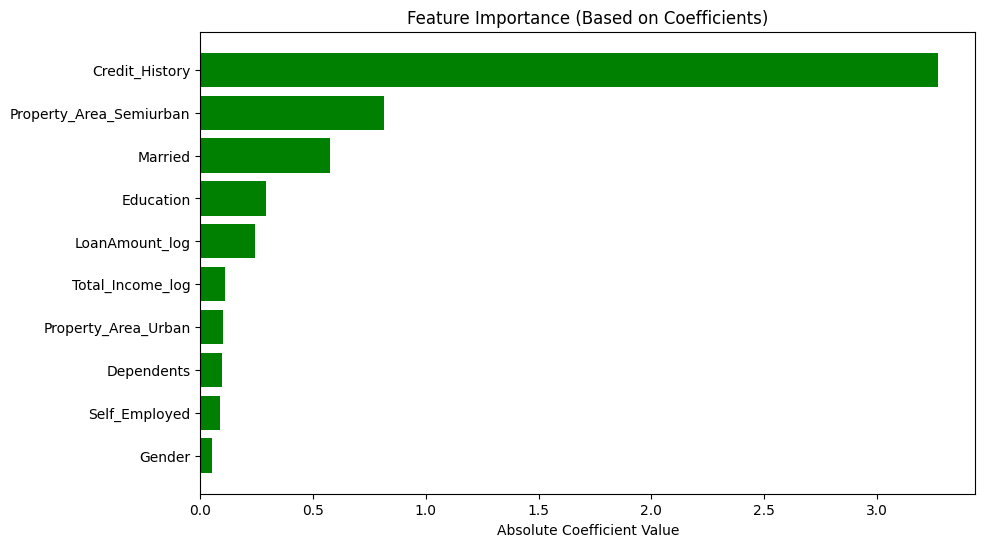

In [ ]:
# Visualize Feature Importance For Logistic Regression
# 1. Coefficients nikalen (Absolute values lein taakay +ive/-ive dono ka asar dikhe)
importances = np.abs(lr.coef_[0]) 
features = x.columns # Ya aapki feature list

# 2. Sort karein
indices = np.argsort(importances)

# 3. Plot karein
plt.figure(figsize=(10, 6))
plt.title('Feature Importance (Based on Coefficients)')
plt.barh(range(len(indices)), importances[indices], color='green', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Absolute Coefficient Value')
plt.show()


# **Result Analysis**

In [60]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [63]:
# 1. y_predict
y_pred = lr.predict(X_test)
# 2. Accuracy Score
acc = accuracy_score(Y_test, y_pred)
print(f"Overall Accuracy: {acc*100:.2f}%")
print("-" * 30)

Overall Accuracy: 78.86%
------------------------------


In [64]:
# 3. Classification Report
print("Classification Report: ")
print(classification_report(Y_test, y_pred))

Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



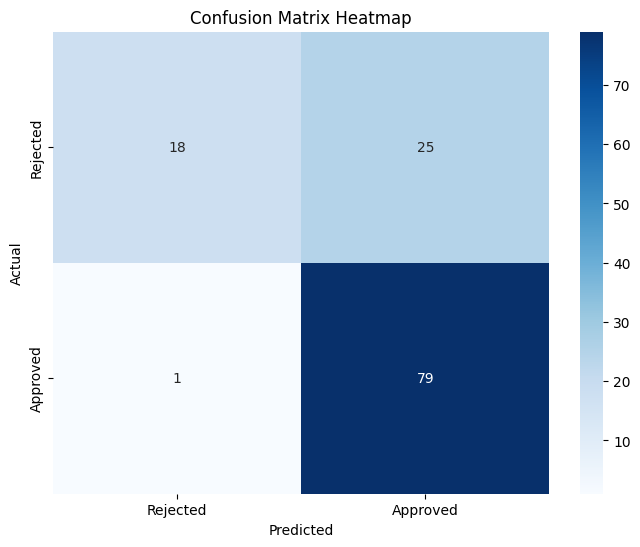

In [65]:
# 4. Confusion Matrix Heatmap
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rejected', 'Approved'], 
            yticklabels=['Rejected', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

# RandomForest

In [66]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize and Train Random Forest
# We use n_estimators=100 and balanced class weights to maintain the fix for rejected loans
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, Y_train)

# 2. Evaluate Random Forest
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(Y_test, y_pred_rf)

print(f'Random Forest Accuracy: {rf_acc*100:.2f}%')
print('\nRandom Forest Performance Report:\n', classification_report(Y_test, y_pred_rf))

Random Forest Accuracy: 75.61%

Random Forest Performance Report:
               precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



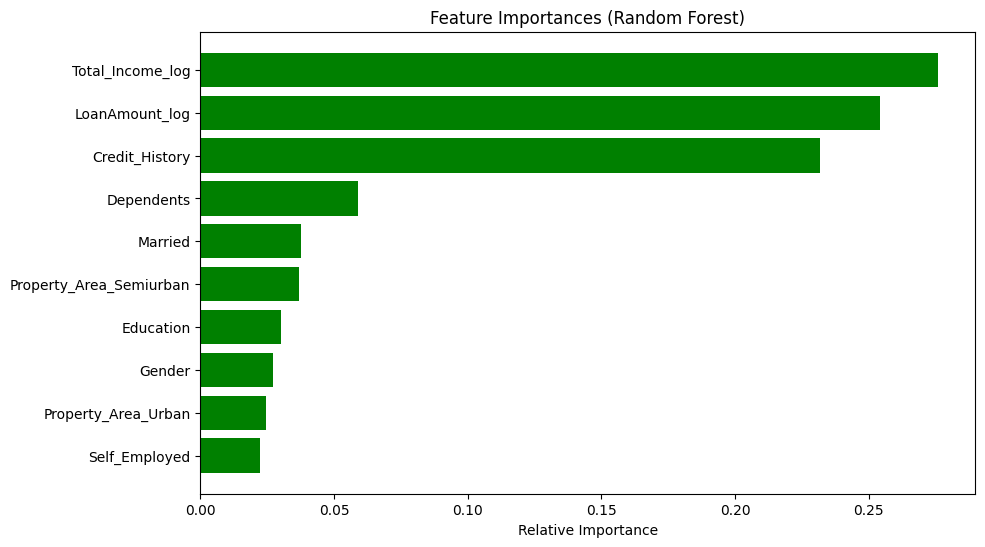

In [67]:
# 3. Visualize Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='green', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()